# Coding Practice Session 6
## Regression Plots in Seaborn

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
tips = sns.load_dataset("tips")

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


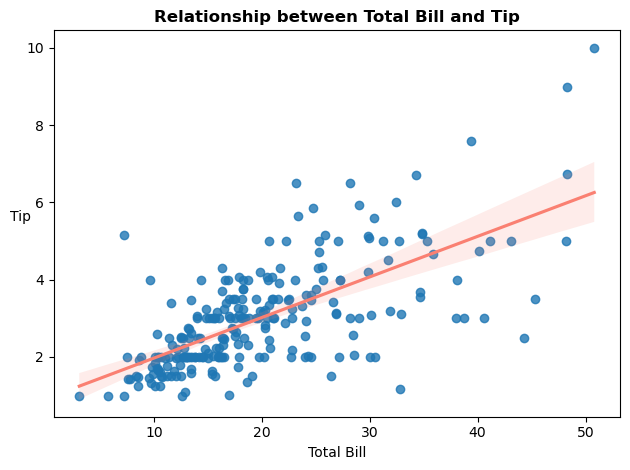

In [4]:
sns.regplot(data=tips, x="total_bill", y="tip", line_kws=dict(color="salmon"))
plt.title("Relationship between Total Bill and Tip", fontweight="bold")
plt.xlabel("Total Bill")
plt.ylabel("Tip", rotation=0)
plt.tight_layout()

### Regression Visualization with `regplot()`

In [5]:
mpg = sns.load_dataset("mpg")

In [6]:
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [7]:
mpg.shape

(398, 9)

In [8]:
list(mpg.columns)

['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model_year',
 'origin',
 'name']

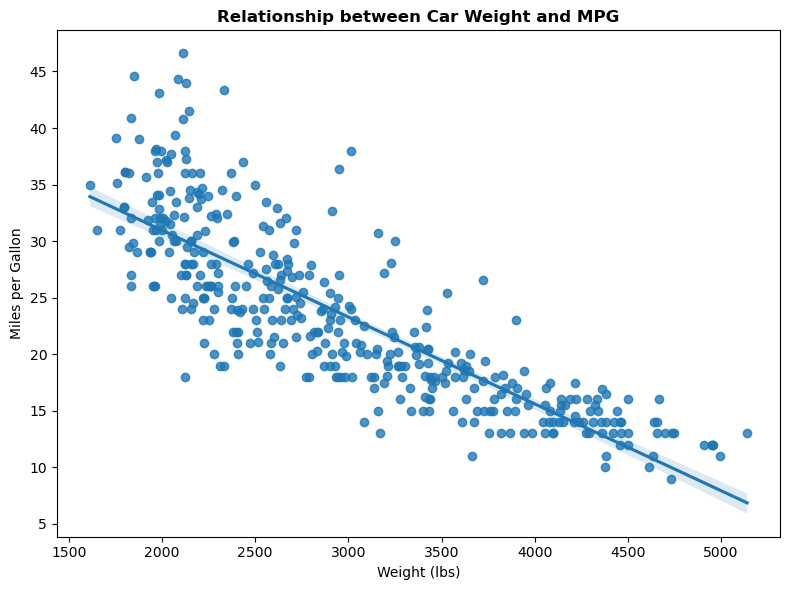

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=mpg, ax=ax, x="weight", y="mpg")
ax.set_title("Relationship between Car Weight and MPG", fontweight="bold")
ax.set(xlabel="Weight (lbs)", ylabel="Miles per Gallon")

fig.tight_layout()

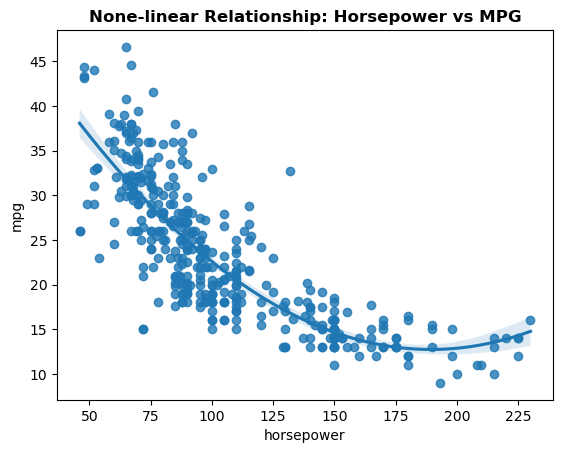

In [10]:
g = sns.regplot(data=mpg, x="horsepower", y="mpg", order=2)
_ = g.set_title("None-linear Relationship: Horsepower vs MPG", fontweight="bold")

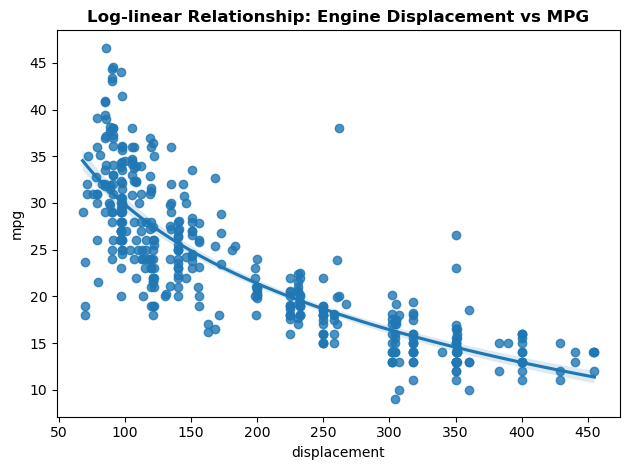

In [11]:
sns.regplot(data=mpg, x="displacement", y="mpg", logx=True)
plt.title("Log-linear Relationship: Engine Displacement vs MPG", fontweight="bold")
plt.tight_layout()

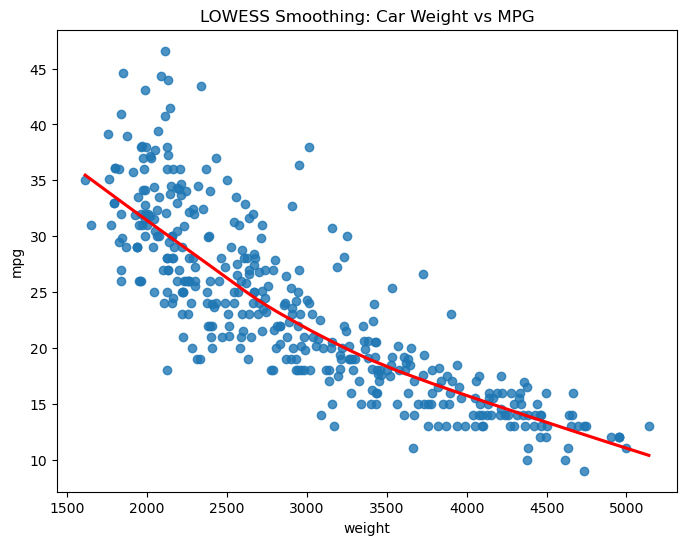

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=mpg, ax=ax, x="weight", y="mpg", lowess=True, line_kws={"color": "red"}
)
_ = ax.set_title("LOWESS Smoothing: Car Weight vs MPG")

In [13]:
# generating Data
n = 1000
x = np.linspace(0, 10, num=n)
y = 0.5 * np.sin(5 * x) + x**3 * 0.01

# adding Noise
noise = np.random.normal(0, 0.2, size=n)
y_noisy = y + noise

In [14]:
df = pd.DataFrame({"x": x, "y": y_noisy})
df.head()

,x,y
0,0.00000,0.006294
1,0.01001,-0.130436
2,0.02002,-0.088927
3,0.03003,0.175702
4,0.04004,0.309828


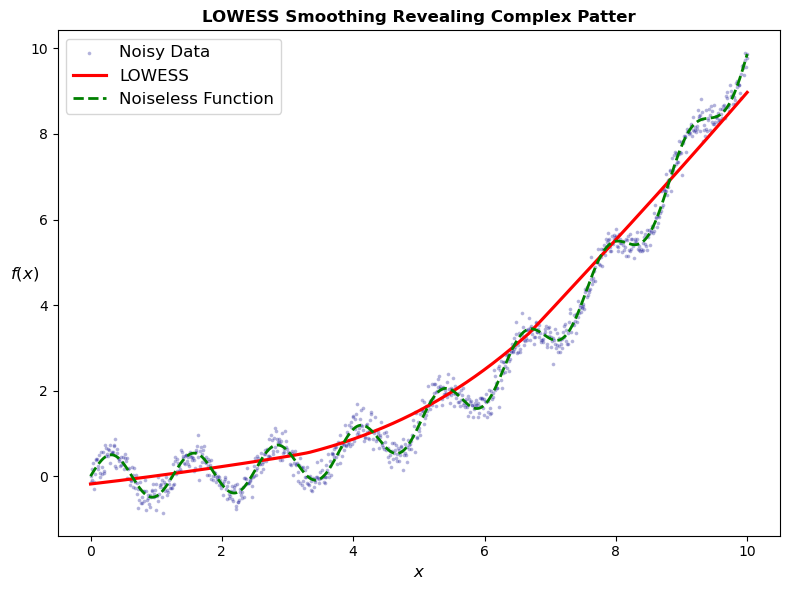

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
# Noisy Data
sns.scatterplot(
    data=df, ax=ax, x="x", y="y", alpha=0.3, color="darkblue", label="Noisy Data", s=7
)

# LOWESS smoothing
sns.regplot(
    data=df,
    ax=ax,
    x="x",
    y="y",
    lowess=True,
    scatter=False,
    color="red",
    label="LOWESS",
)

# True Function
sns.lineplot(
    x=x, y=y, color="green", linestyle="--", linewidth=2, label="Noiseless Function"
)

ax.set_title("LOWESS Smoothing Revealing Complex Patter", fontweight="bold")
ax.set_ylabel("$f(x)$", rotation=0, fontsize=12)
ax.set_xlabel("$x$", fontsize=12)
ax.legend(fontsize=12)

fig.tight_layout()

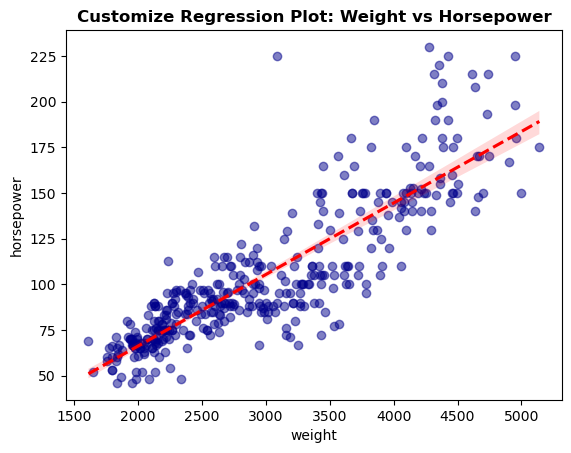

In [16]:
sns.regplot(
    data=mpg,
    x="weight",
    y="horsepower",
    scatter_kws={"color": "darkblue", "alpha": 0.5},
    line_kws={"color": "red", "linestyle": "--"},
)
_ = plt.title("Customize Regression Plot: Weight vs Horsepower", fontweight="bold")

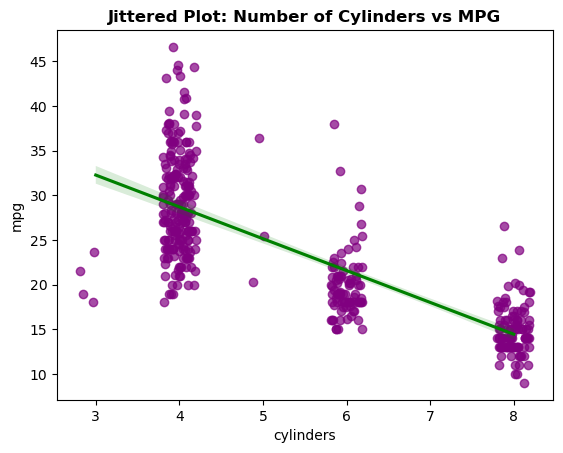

In [17]:
sns.regplot(
    data=mpg,
    x="cylinders",
    y="mpg",
    x_jitter=0.2,
    color="purple",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "green"},
)
_ = plt.title("Jittered Plot: Number of Cylinders vs MPG", fontweight="bold")

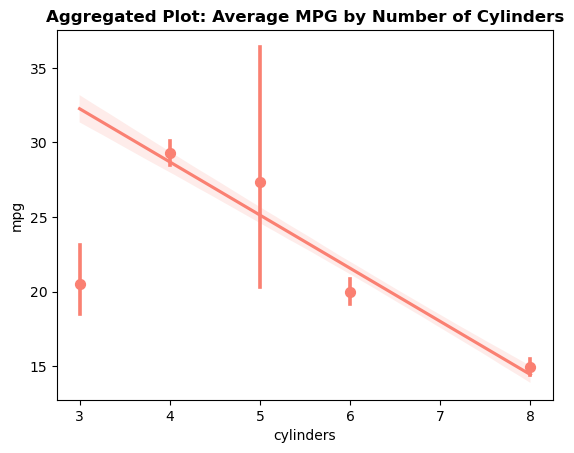

In [18]:
ax = sns.regplot(data=mpg, x="cylinders", y="mpg", x_estimator=np.mean, color="salmon")
_ = ax.set_title(
    "Aggregated Plot: Average MPG by Number of Cylinders", fontweight="bold"
)

In [19]:
mpg.head(6)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500


In [20]:
mpg["from_usa"] = (mpg["origin"] == "usa").astype(np.int8)

In [21]:
mpg

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,from_usa
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,1
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,1
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,1
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,1
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,1
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl,1
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup,0
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage,1
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger,1


In [22]:
mpg["from_usa"].value_counts()

from_usa
1    249
0    149
Name: count, dtype: int64

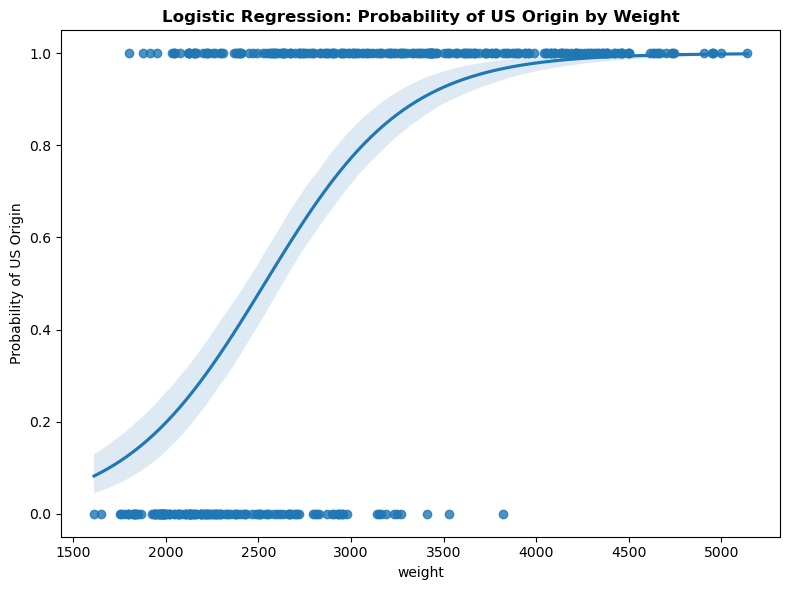

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=mpg, ax=ax, x="weight", y="from_usa", logistic=True)
ax.set_title(
    "Logistic Regression: Probability of US Origin by Weight", fontweight="bold"
)
ax.set_ylabel("Probability of US Origin")

fig.tight_layout()

### Robust Regression

In [24]:
x = np.random.normal(loc=0, scale=1, size=100)
y = 0.5 * x + np.random.normal(loc=0, scale=0.5, size=100)

In [25]:
y

array([ 0.38778417,  0.4370327 , -0.63684773,  0.7988741 , -0.15884107,
        0.94076671,  0.27758374, -0.03960399, -1.63795964, -0.74681432,
        1.13354029,  0.3841655 ,  1.0710922 ,  0.30192401,  0.27724872,
       -0.30590236, -1.04182583, -1.09116027, -0.17364086, -0.33842184,
        0.61834398,  1.12630867, -0.22826959,  0.27484295,  0.47433937,
       -0.32021401, -0.95390752, -0.3372021 ,  0.88116946,  1.76308508,
       -0.77241751, -0.40487708,  0.71760703,  1.34404205, -0.60667447,
       -0.176288  , -0.73021372,  0.81918239,  0.54603291,  0.26537875,
        0.6154195 ,  0.61162856, -0.76883179,  1.53803846, -0.44690375,
       -0.68986717, -0.24098616, -2.44720745,  0.50903153, -0.45020486,
        0.62678606, -0.97017491, -0.43925775, -1.32090918, -0.07469701,
       -0.36131075, -0.62488554,  0.30463348,  0.87350082, -0.37155222,
       -0.00532297, -0.5381601 , -0.04936263,  0.10115393,  0.89285228,
        0.16659139,  0.65350136,  1.60417234,  0.33843329,  0.24

In [26]:
y[10] = 10
y[20] = -10
y[30] = 15
y[40] = -150
y[50] = 20
y[60] = -200
y[70] = 250
y[80] = -25
y[90] = 300

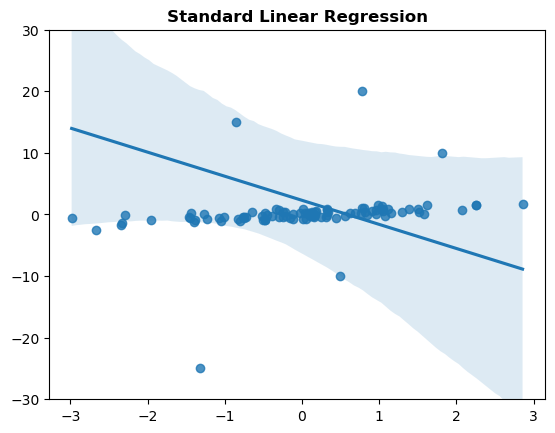

In [27]:
# uses ordinary least squares algorithm
ax = sns.regplot(x=x, y=y)
ax.set_title("Standard Linear Regression", fontweight="bold")
_ = ax.set_ylim(-30, 30)

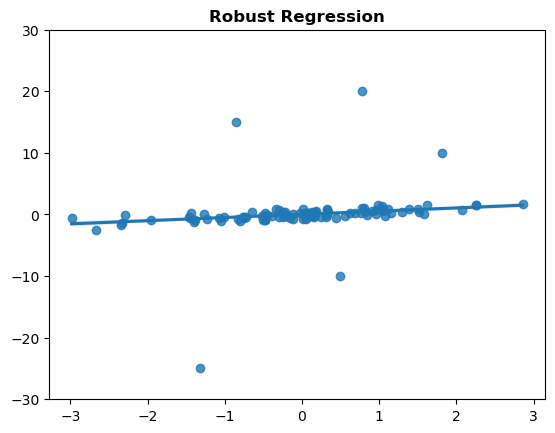

In [28]:
# uses Huber algorithm to offset the effect of outliers
ax = sns.regplot(x=x, y=y, robust=True)
ax.set_title("Robust Regression", fontweight="bold")
_ = ax.set_ylim(-30, 30)

### Regression Visualization with `lmplot()`

In [29]:
penguins = sns.load_dataset("penguins")

In [30]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [31]:
penguins["species"].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

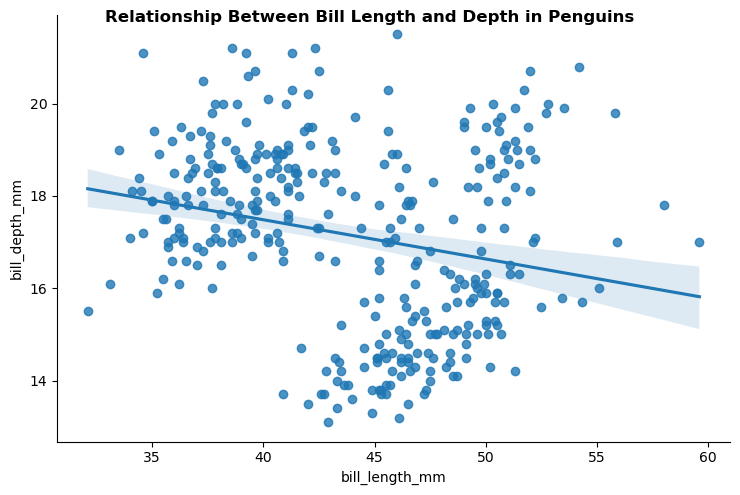

In [32]:
g = sns.lmplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", aspect=1.5)
_ = g.figure.suptitle(
    "Relationship Between Bill Length and Depth in Penguins", fontweight="bold"
)

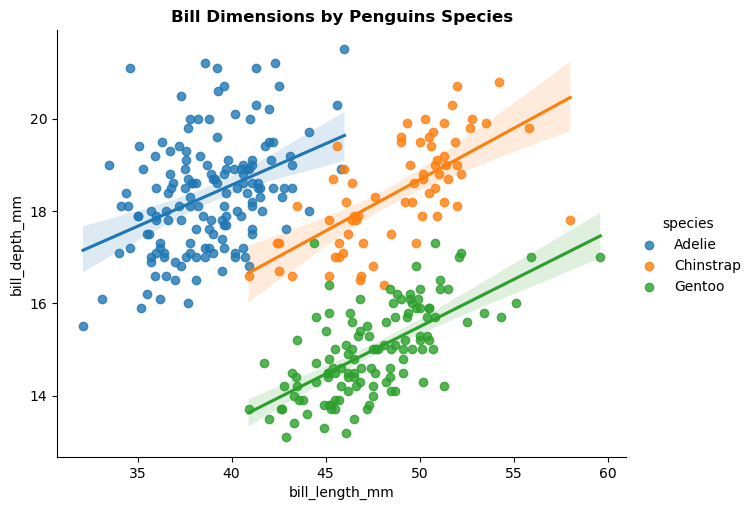

In [ ]:
sns.lmplot(
    data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", aspect=1.3
)
_ = plt.title("Bill Dimensions by Penguins Species", fontweight="bold")

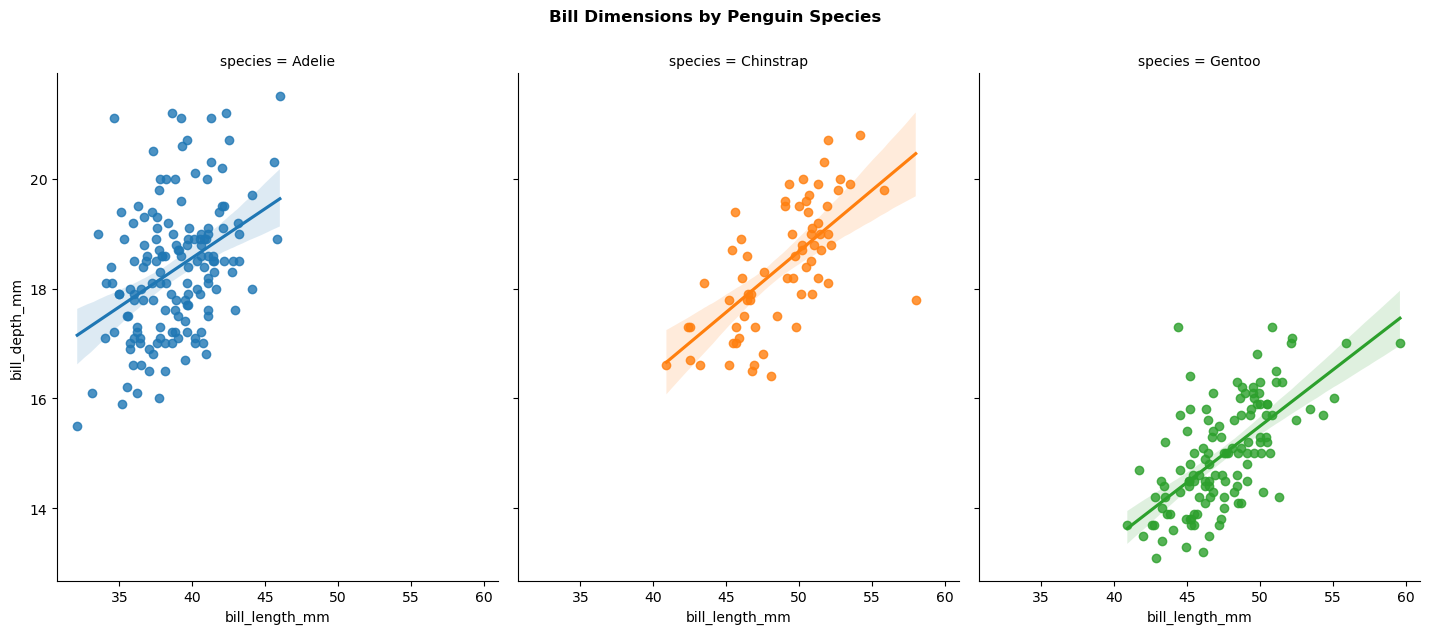

In [ ]:
sns.lmplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    col="species",
    hue="species",
    height=6,
    aspect=0.8,
)

_ = plt.suptitle("Bill Dimensions by Penguin Species", y=1.05, fontweight="bold")

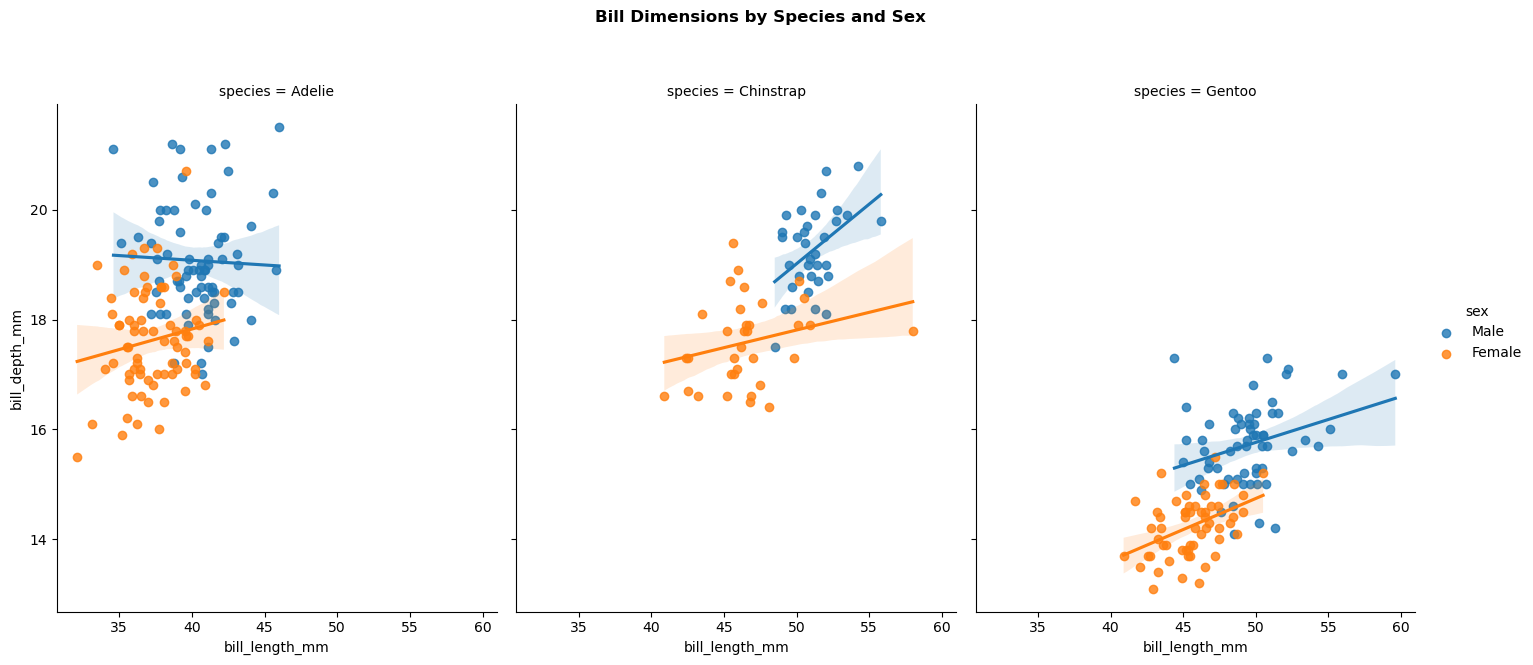

In [ ]:
sns.lmplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="sex",
    col="species",
    height=6,
    aspect=0.8,
)

_ = plt.suptitle("Bill Dimensions by Species and Sex", fontweight="bold", y=1.1)

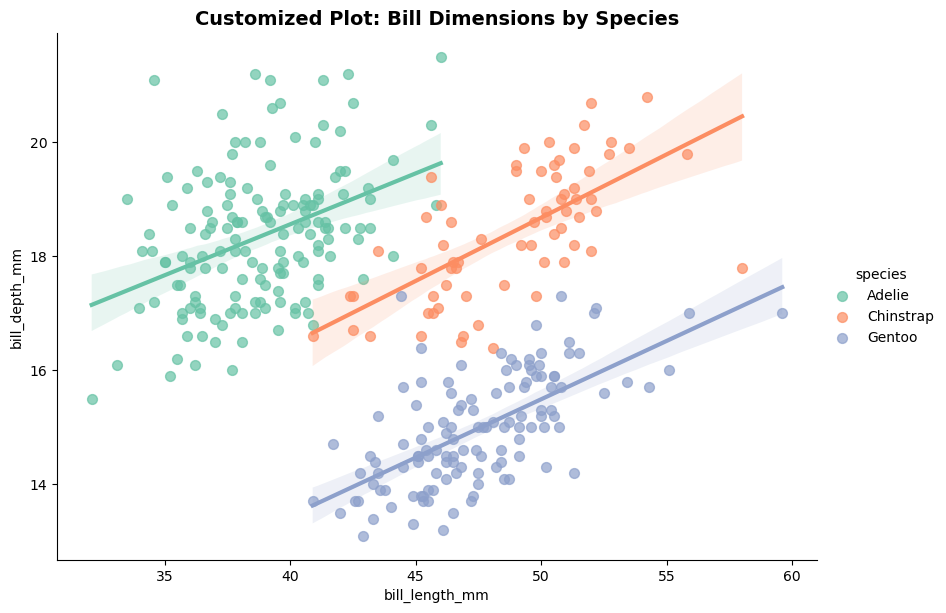

In [ ]:
g = sns.lmplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    height=6,
    aspect=1.4,
    palette="Set2",
    scatter_kws=dict(s=50, alpha=0.7),
    line_kws={"linewidth": 3},
)
_ = plt.title(
    "Customized Plot: Bill Dimensions by Species", fontweight="bold", fontsize=14
)

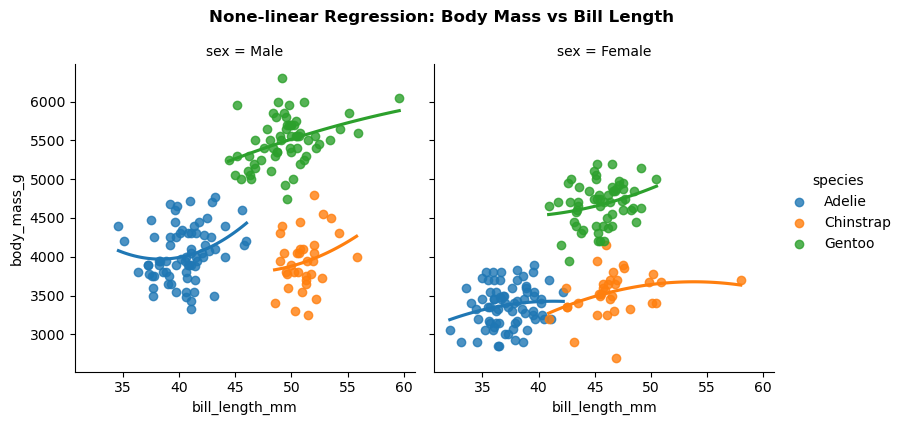

In [ ]:
sns.lmplot(
    data=penguins,
    x="bill_length_mm",
    y="body_mass_g",
    hue="species",
    col="sex",
    height=4,
    aspect=1,
    order=2,
    ci=None,
)
_ = plt.suptitle(
    "None-linear Regression: Body Mass vs Bill Length", y=1.05, fontweight="bold"
)

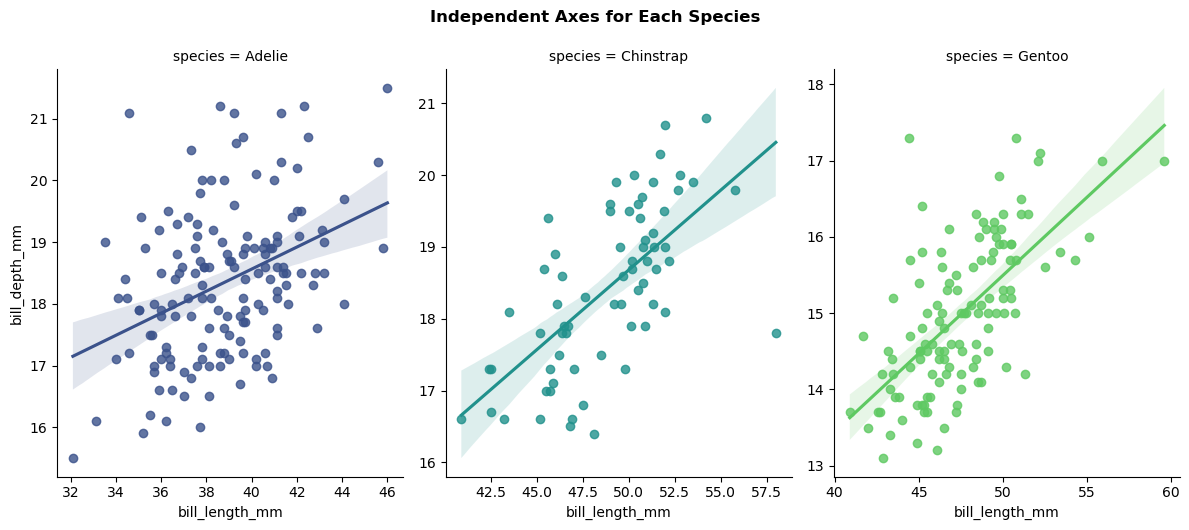

In [ ]:
sns.lmplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    col="species",
    hue="species",
    palette="viridis",
    height=5,
    aspect=0.8,
    facet_kws={"sharex": False, "sharey": False},
)
_ = plt.suptitle("Independent Axes for Each Species", fontweight="bold", y=1.05)

Residual Analysis with `residplot()`

In [40]:
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,from_usa
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,1
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,1
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,1
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,1
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,1


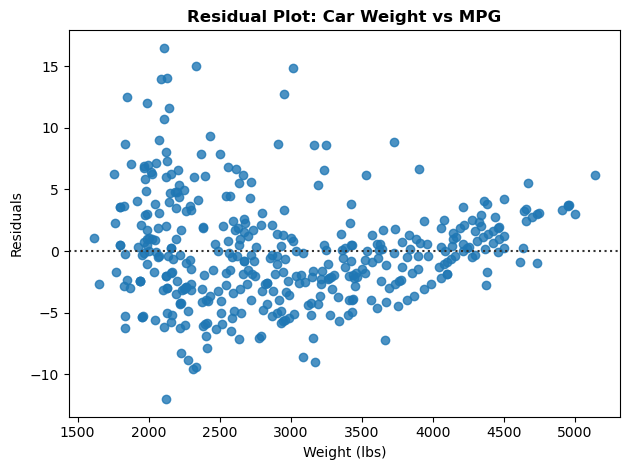

In [42]:
sns.residplot(data=mpg, x="weight", y="mpg")
plt.title("Residual Plot: Car Weight vs MPG", fontweight="bold")
plt.xlabel("Weight (lbs)")
plt.ylabel("Residuals")
plt.tight_layout()

In [43]:
np.random.seed(7)
x = np.linspace(0, 10, 100)
y = 2 * x + 1 + np.random.normal(0, 1, 100)

In [44]:
y

array([ 2.6905257 ,  0.73608283,  1.43686057,  2.01357689,  1.01915778,
        2.01216658,  2.21123083,  0.65941711,  3.63381962,  3.41868033,
        2.39477305,  3.05067396,  3.9295418 ,  3.36490621,  3.58553375,
        2.57706162,  4.78690354,  4.55822434,  4.91082356,  3.31185931,
        6.69110373,  5.39675978,  5.0573045 ,  7.67553687,  5.80309882,
        4.59982635,  5.8472974 ,  4.16623035,  7.70596221,  6.44211154,
        6.31805254,  8.33509639,  5.81357088,  8.20209602,  5.80427207,
        7.40854773,  7.06850743,  9.9367231 , 10.44292855,  8.54937413,
        9.92154132,  9.10284188, 10.05291037,  8.93403149,  8.18054969,
        8.28781043, 10.67605114, 12.74254455, 10.96638133, 10.37438528,
       13.01302896, 11.54033215, 11.60648449, 11.95964844, 11.77671371,
       11.80163477, 10.87816785, 13.01677564, 12.62239627, 14.11227784,
       12.75239365, 11.41686244, 13.42564189, 15.42681002, 13.54586981,
       13.24145627, 13.13974141, 13.48533672, 14.43718   , 13.75

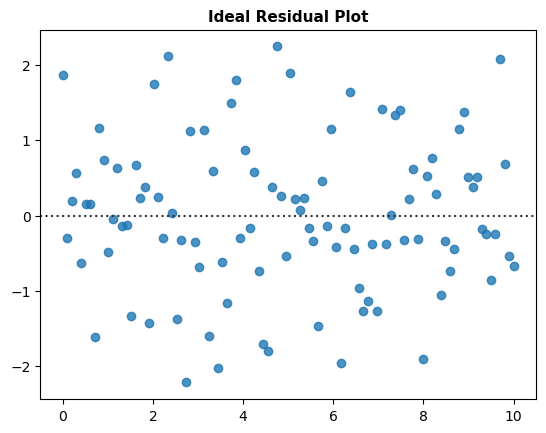

In [ ]:
# residuals scattered evenly around 0
sns.residplot(x=x, y=y)
_ = plt.title("Ideal Residual Plot", fontweight="bold", fontsize=11)

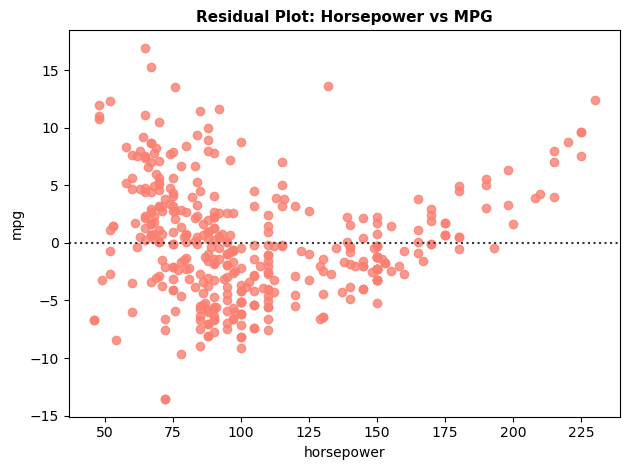

In [47]:
# predicting a non-linear relationship with a linear regression model
g = sns.residplot(data=mpg, x="horsepower", y="mpg", color="salmon")
g.set_title("Residual Plot: Horsepower vs MPG", fontweight="bold", fontsize=11)
g.figure.tight_layout()

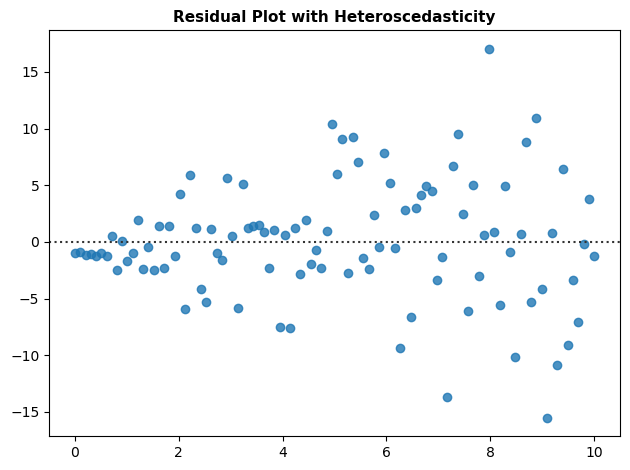

In [48]:
np.random.seed(25)
x = np.linspace(0, 10, 100)
y = 2 * x + 1 + np.random.normal(0, x, 100)

# simulating heteroscedasticity
sns.residplot(x=x, y=y)
plt.title("Residual Plot with Heteroscedasticity", fontweight="bold", fontsize=11)
plt.tight_layout()

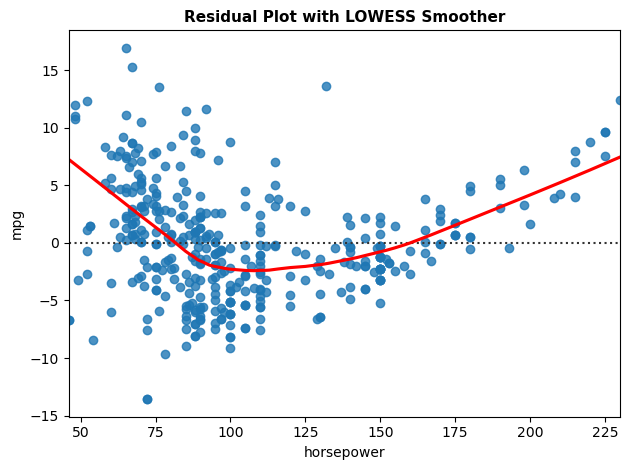

In [49]:
sns.residplot(data=mpg, x="horsepower", y="mpg", lowess=True, line_kws={"color": "red"})
plt.title("Residual Plot with LOWESS Smoother", fontweight="bold", fontsize=11)
plt.tight_layout()

In [50]:
x = np.random.normal(0, 1, 100)
y = x**2 + 0.1 + np.random.normal(0, 1, 100)

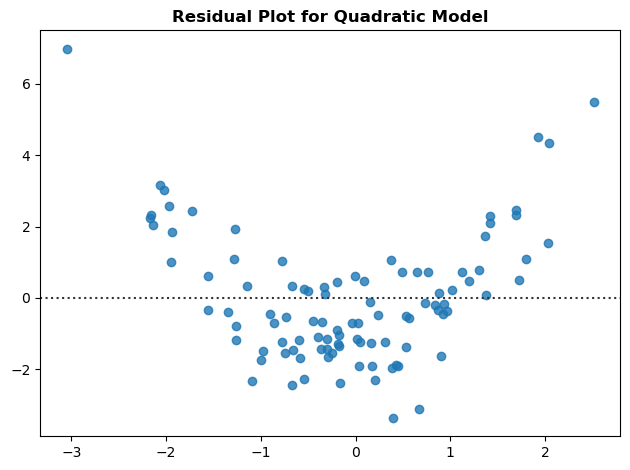

In [51]:
sns.residplot(x=x, y=y, order=1)
plt.title("Residual Plot for Quadratic Model", fontweight="bold", fontsize=12)
plt.tight_layout()

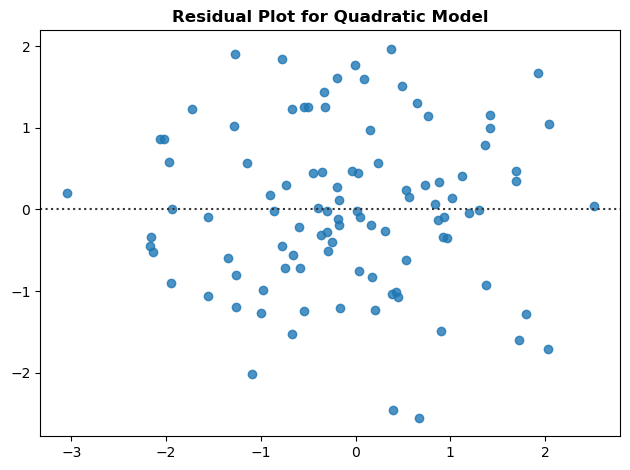

In [52]:
sns.residplot(x=x, y=y, order=2)
plt.title("Residual Plot for Quadratic Model", fontweight="bold", fontsize=12)
plt.tight_layout()

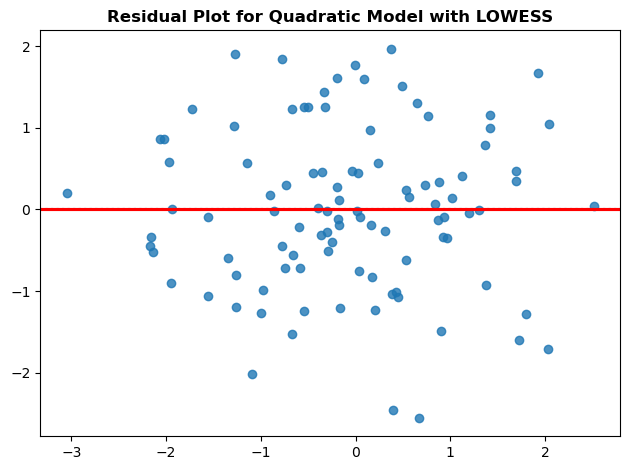

In [ ]:
sns.residplot(x=x, y=y, order=2, lowess=True, line_kws=dict(color="red"))
plt.title(
    "Residual Plot for Quadratic Model with LOWESS", fontweight="bold", fontsize=12
)
plt.tight_layout()

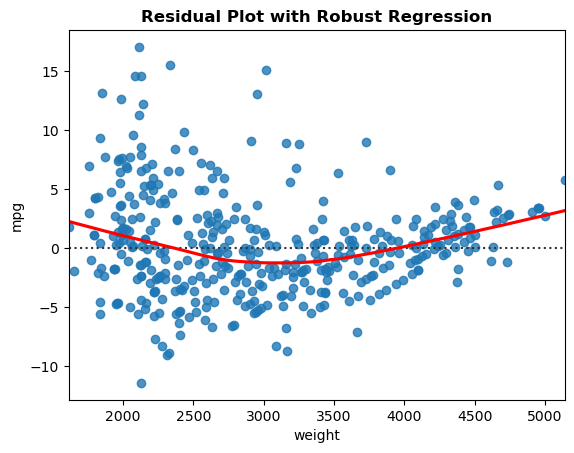

In [ ]:
g = sns.residplot(
    data=mpg, x="weight", y="mpg", robust=True, lowess=True, line_kws={"color": "red"}
)
_ = g.set_title("Residual Plot with Robust Regression", fontweight="bold")

### Regression in Other Contexts: `jointplot()` and `pairplot()`

In [59]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


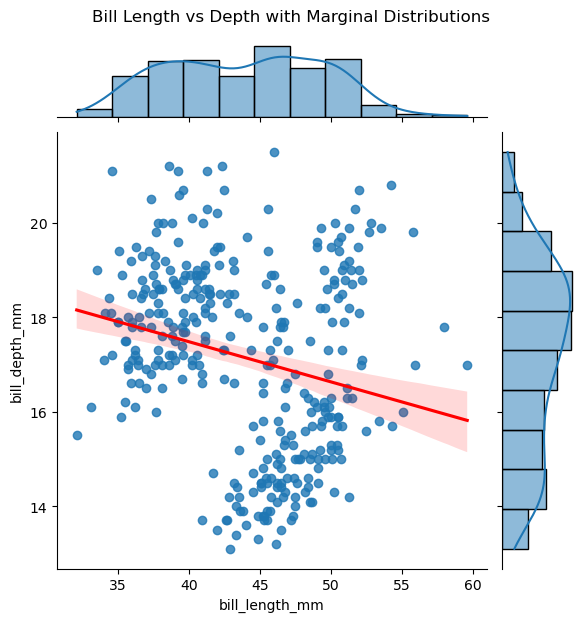

In [70]:
g = sns.jointplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    kind="reg",
    line_kws=dict(color="red")
)
_ = g.figure.suptitle("Bill Length vs Depth with Marginal Distributions", y=1.03)

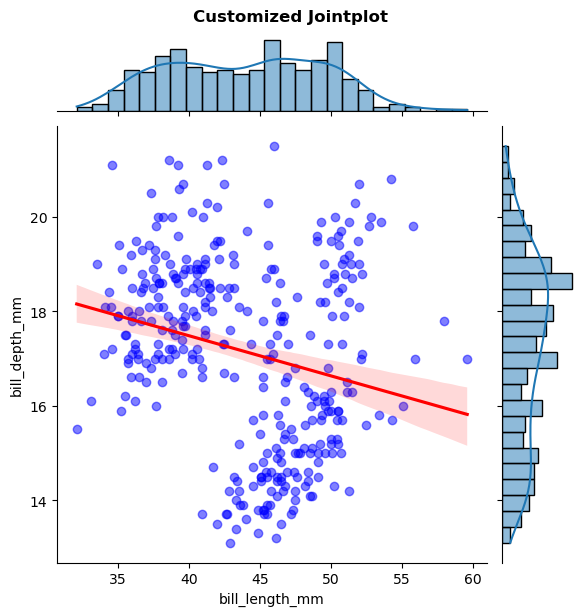

In [72]:
sns.jointplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    kind="reg",
    scatter_kws={"color": "blue", "alpha": 0.5},
    line_kws=dict(color="r"),
    marginal_kws=dict(bins=25, fill=True)
)
_ = plt.suptitle("Customized Jointplot", fontweight="bold", y=1.02)

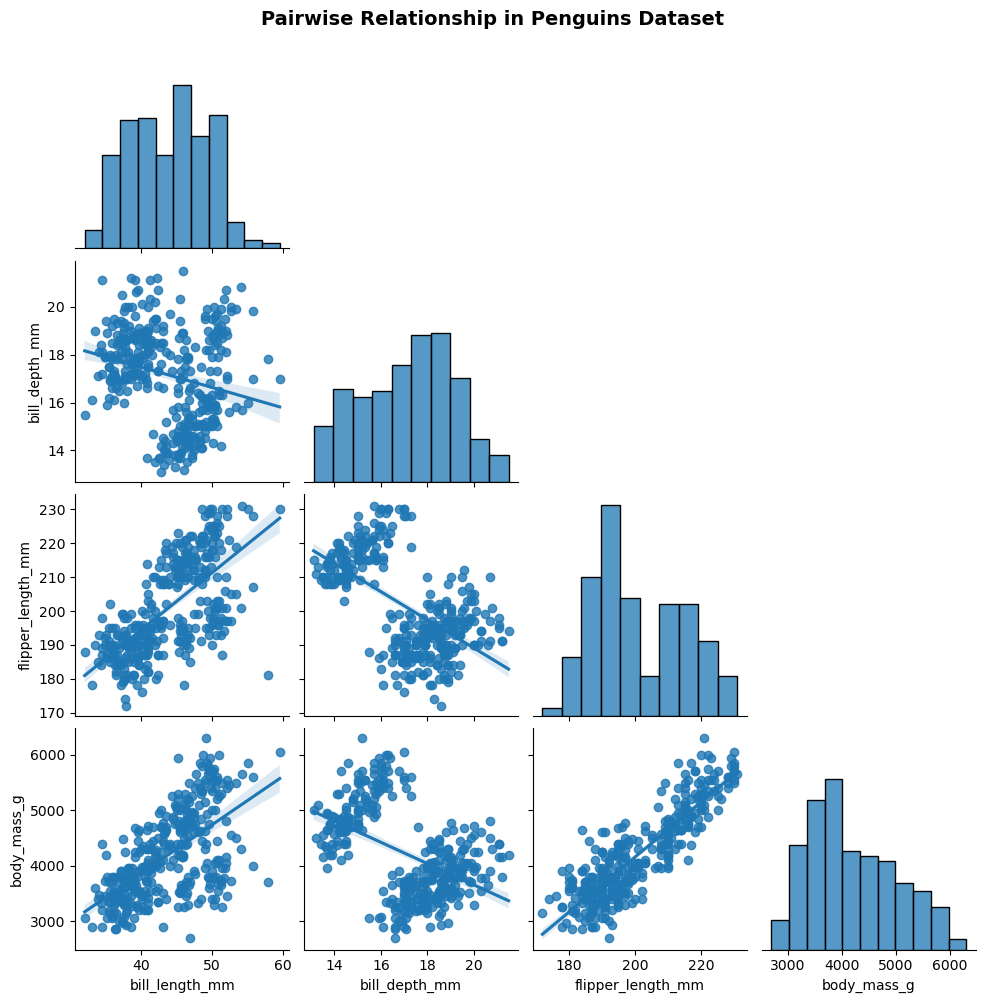

In [74]:
sns.pairplot(data=penguins, kind="reg", corner=True)
_ = plt.suptitle("Pairwise Relationship in Penguins Dataset", fontweight="bold", fontsize=14, y=1)

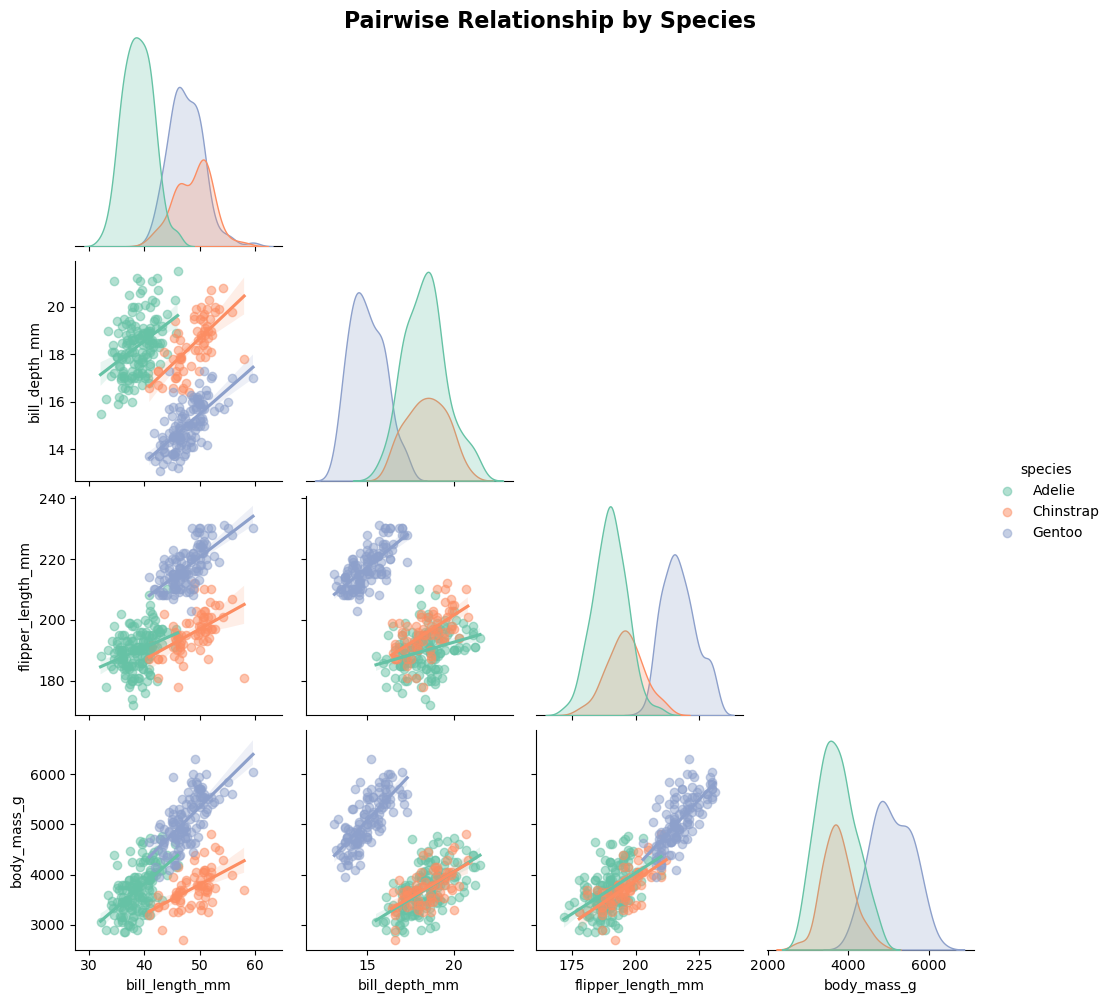

In [76]:
sns.pairplot(
    data=penguins,
    kind="reg",
    hue="species",
    palette="Set2",
    plot_kws={"scatter_kws": {"alpha": 0.5}},
    corner=True
)
_ = plt.suptitle("Pairwise Relationship by Species", fontweight="bold", fontsize=16, y=1)

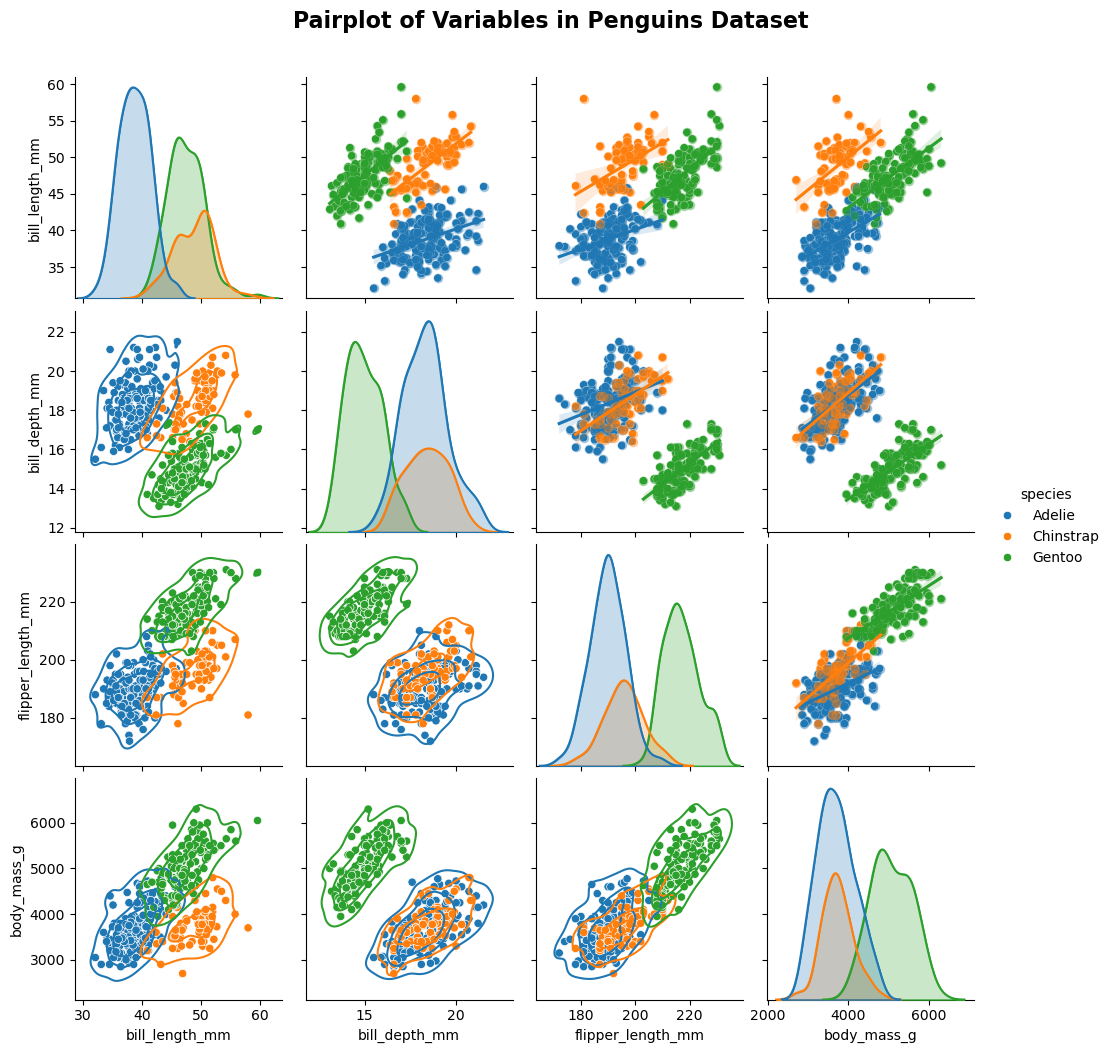

In [87]:
g = sns.pairplot(data=penguins, hue="species")
g.map_lower(sns.kdeplot, color="black", levels=4)
g.map_diag(sns.kdeplot)
g.map_upper(sns.regplot, scatter_kws={"alpha": 0.3})

_ = g.figure.suptitle("Pairplot of Variables in Penguins Dataset", fontweight="bold", fontsize=16, y=1.05)